In [117]:
import pandas as pd                             # pandas
import numpy as np                              # numpy
import matplotlib.pyplot as plt                 # matplotlib
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # - 깨짐 방지
data1 = pd.read_csv('./kdrama.csv')             # 드라마 데이터 가져오기

In [118]:
# 컬럼명 한글로 변환
data1 = data1.rename(columns={
    "Name": "작품명","Aired Date": "방영 기간","Year of release": "공개 연도","Original Network": "원작 방송사","Aired On": "방영 요일"
    , "Number of Episodes": "총 에피 수","Duration": "회당 러닝타임","Content Rating": "시청 등급", "Rating": "평점","Synopsis": "줄거리"
    , "Genre": "장르","Tags": "태그","Director": "감독","Screenwriter": "각본","Cast": "출연진","Production companies": "제작사","Rank": "순위"
})
# 전체 장르명 한글로 변환해줄 딕셔너리
genre_kr = {
    'Romance': '로맨스','Drama': '드라마','Mystery': '미스터리','Comedy': '코미디','Thriller': '스릴러','Life': '일상','Action': '액션'
    ,'Melodrama': '멜로드라마','Historical': '사극','Fantasy': '판타지','Law': '법정','Crime': '범죄','Supernatural': '초자연','Psychological': '심리'
    ,'Political': '정치','Youth': '청춘','Medical': '의학','Family': '가족','Horror': '공포','Sci-Fi': 'SF','Friendship': '우정'
    ,'Business': '비즈니스','Sports': '스포츠','Military': '군대','Music': '음악','Adventure': '모험','Food': '음식','School': '학원','Sitcom': '시트콤'
}

def translate_genres(genre_str):
    if pd.isna(genre_str):
        return genre_str

    genres = [g.strip() for g in genre_str.split(',')]
    return ', '.join(genre_kr.get(g, g) for g in genres)

data1['장르'] = data1['장르'].apply(translate_genres)
data1['장르']

0              일상, 드라마, 가족
1      스릴러, 로맨스, 범죄, 멜로드라마
2          우정, 로맨스, 일상, 의학
3          우정, 로맨스, 일상, 의학
4          심리, 일상, 드라마, 가족
              ...         
245       사극, 로맨스, 의학, 판타지
246     사극, 로맨스, 멜로드라마, 정치
247       법정, 로맨스, 일상, 드라마
248      공포, 코미디, 로맨스, 판타지
249      액션, 스릴러, 미스터리, 범죄
Name: 장르, Length: 250, dtype: object

In [119]:
# 필요한 컬럼만 가져와서 DataFrame 새로 만들기
df1 = data1[['작품명', '장르', '공개 연도', '평점', '순위']].copy()
# 2010년 이전의 데이터는 데이터의 크기가 너무 작아 유의미한 의미를 가지지 못할것 같아 2010년 이전 데이터는 전부 제외
df1 = df1[df1['공개 연도'] >= 2010]                                
df1

,작품명,장르,공개 연도,평점,순위
0,Move to Heaven,"일상, 드라마, 가족",2021,9.2,#1
1,Flower of Evil,"스릴러, 로맨스, 범죄, 멜로드라마",2020,9.1,#2
2,Hospital Playlist,"우정, 로맨스, 일상, 의학",2020,9.1,#3
3,Hospital Playlist 2,"우정, 로맨스, 일상, 의학",2021,9.1,#4
4,My Mister,"심리, 일상, 드라마, 가족",2018,9.1,#5
...,...,...,...,...,...
245,Live Up to Your Name,"사극, 로맨스, 의학, 판타지",2017,8.3,#246
246,Queen for Seven Days,"사극, 로맨스, 멜로드라마, 정치",2017,8.3,#247
247,Memory,"법정, 로맨스, 일상, 드라마",2016,8.3,#248
248,A Korean Odyssey,"공포, 코미디, 로맨스, 판타지",2017,8.3,#249


# 가설2. 사회불안요소가 장르 선호도 변화와 연관이 있을까?
## 그룹핑 : 국정농단사건 전 : 2010 - 2016 / 국정농단사건 후 : 2017 - 2020 
## / 코로나 사태 : 2020 - 2022 

In [120]:
ur1 = df1[df1['공개 연도'] <= 2016]
ur2 = df1[(df1['공개 연도'] > 2016) & (df1['공개 연도'] <= 2020)]
ur3 = df1[df1['공개 연도'] > 2020]

In [121]:
# 1. 2016년까지의 데이터 문자열로 변환 개행 시켜주는 이스케이프 문자 제거
# 2. ','를 기준으로 분리 
# 3. 공백 제거
# 4. 몇개인지 세주고
# 5. 그중에 indcx를 뽑아서 리스트화
ur1_g = ur1['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ur2_g = ur2['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ur3_g = ur3['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()

In [130]:
def makeDf(df, g, store, name):
    dic = {}
    for i in g:
        dic[i] = df[df['장르'].str.contains(i)]['평점']

    store[name] = pd.DataFrame({
        '갯수': {genre: len(ratings) for genre, ratings in dic.items()},
        '평균 평점': {genre: ratings.mean() for genre, ratings in dic.items()},
        '선호도': {genre: (ratings.mean() * np.log(len(ratings) + 1)) for genre, ratings in dic.items()}
    })

    store[name]['평균 평점'] = store[name]['평균 평점'].round(2)
    store[name]['선호도'] = store[name]['선호도'].round(2)

    store[name] = store[name].sort_values('선호도', ascending=False)

In [131]:
# 차트 그리는 함수  
def draw_chart(x,y,t):             # 매개변수 x => x축 / y => y축 / t => 차트 제목
    plt.figure(figsize=(12, 6))    # 차트 크기 키우고
    plt.xticks(rotation=45)        # x축의 이름 45도 기울이기 ==> 보기 편하게
    plt.grid(True, linestyle='--', alpha=0.6)     # 점선 넣기
    plt.title(t)
    plt.xlabel("장르")
    plt.ylabel("선호도")
    plt.text(0.65, 0.95,'선호도 = 평균 평점 × log(작품 수 + 1)',
        transform = plt.gca().transAxes,
        fontsize = 13,
        verticalalignment='top')
    plt.bar(x,y)                        # 차트에 x축 y축에 데이터 넣기
    plt.show()                           # 차트 그리기

In [132]:
summary_store = {}

makeDf(ur1, ur1_g, summary_store, '농단전')
makeDf(ur2, ur2_g, summary_store, '농단후')
makeDf(ur3, ur3_g, summary_store, '코로나')

ur1_summary = summary_store['농단전']
ur2_summary = summary_store['농단후']
ur3_summary = summary_store['코로나']

<Figure size 640x480 with 0 Axes>

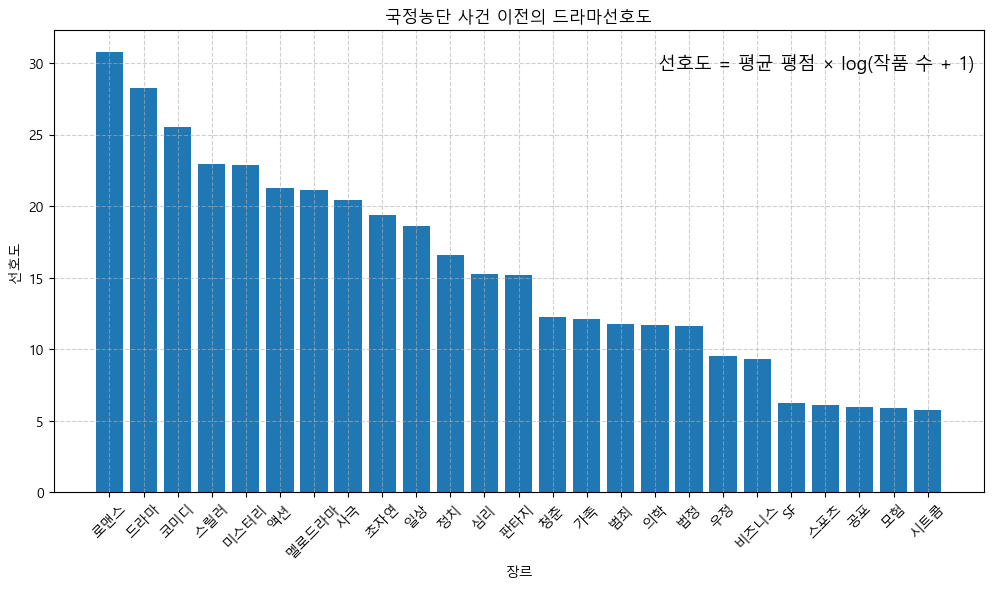

In [133]:
x1 = ur1_summary.index.to_list()
y1 = ur1_summary['선호도'].values
plt.savefig('국정농단 사건 이전의 드라마선호도.png', dpi=300, bbox_inches='tight')
draw_chart(x1,y1,'국정농단 사건 이전의 드라마선호도')

<Figure size 640x480 with 0 Axes>

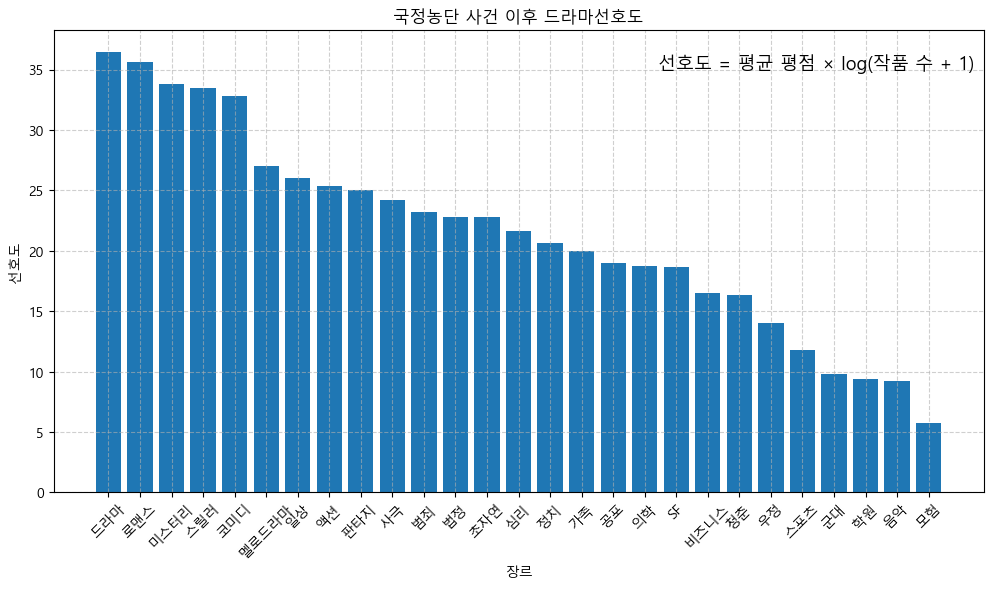

In [134]:
x2 = ur2_summary.index.to_list()
y2 = ur2_summary['선호도'].values
plt.savefig('국정농단 사건 후 드라마선호도.png', dpi=300, bbox_inches='tight')
draw_chart(x2,y2,'국정농단 사건 이후 드라마선호도')

<Figure size 640x480 with 0 Axes>

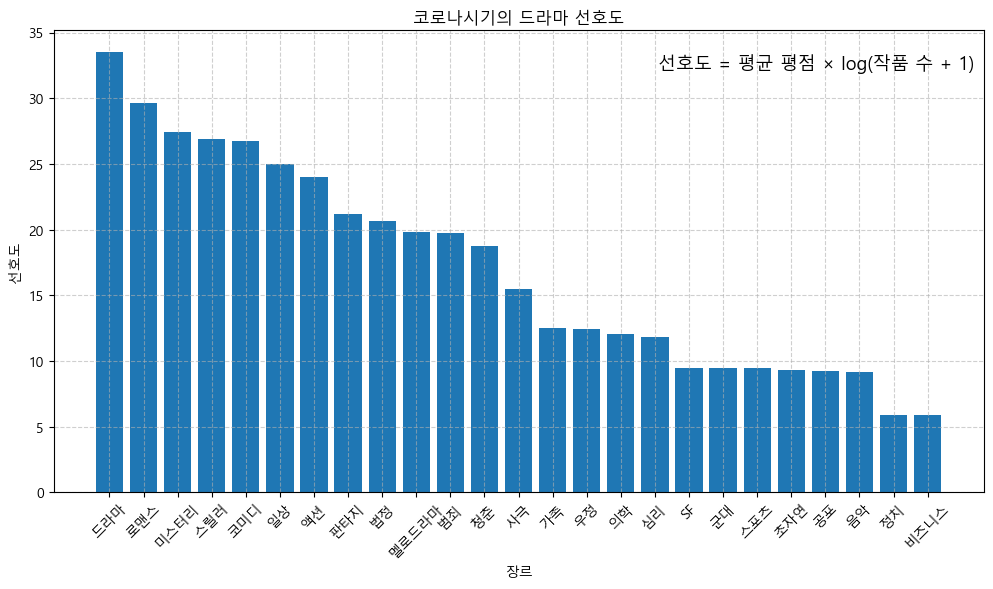

In [135]:
x3 = ur3_summary.index.to_list()
y3 = ur3_summary['선호도'].values
plt.savefig('코로나시기의 드라마 선호도.png', dpi=300, bbox_inches='tight')
draw_chart(x3,y3,'코로나시기의 드라마 선호도')

In [136]:
genre_rank1 = {genre: i+1 for i, genre in enumerate(x1)}
genre_rank2 = {genre: i+1 for i, genre in enumerate(x2)}
genre_rank3 = {genre: i+1 for i, genre in enumerate(x3)}

common_genres = sorted(set(genre_rank1) & set(genre_rank2) & set(genre_rank3))

compare_df = pd.DataFrame({
    '장르': common_genres,
    '농단사건 전': [genre_rank1[g] for g in common_genres],
    '농단사건 후': [genre_rank2[g] for g in common_genres],
    '코로나사태': [genre_rank3[g] for g in common_genres],
})

compare_df = compare_df.sort_values('농단사건 전').reset_index(drop=True)
compare_df

,장르,농단사건 전,농단사건 후,코로나사태
0,로맨스,1,2,2
1,드라마,2,1,1
2,코미디,3,5,5
3,스릴러,4,4,4
4,미스터리,5,3,3
5,액션,6,8,7
6,멜로드라마,7,6,10
7,사극,8,10,13
8,초자연,9,13,21
9,일상,10,7,6


In [137]:
rank_genre1 = {v: k for k, v in genre_rank1.items()}
rank_genre2 = {v: k for k, v in genre_rank2.items()}
rank_genre3 = {v: k for k, v in genre_rank3.items()}

common_ranks = sorted(
    set(rank_genre1) & set(rank_genre2) & set(rank_genre3)
)

compare_df = pd.DataFrame({
    '순위': common_ranks,
    '농단사건 전': [rank_genre1[r] for r in common_ranks],
    '농단사건 후': [rank_genre2[r] for r in common_ranks],
    '코로나사태': [rank_genre3[r] for r in common_ranks],
})

compare_df = compare_df.set_index('순위')
compare_df

,농단사건 전,농단사건 후,코로나사태
순위,,,
1,로맨스,드라마,드라마
2,드라마,로맨스,로맨스
3,코미디,미스터리,미스터리
4,스릴러,스릴러,스릴러
5,미스터리,코미디,코미디
6,액션,멜로드라마,일상
7,멜로드라마,일상,액션
8,사극,액션,판타지
9,초자연,판타지,법정
